In [142]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('./data/house_train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [143]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [144]:
# 결측치가 많은 애들을 뺀다
tmp = df.isnull().sum()
print(tmp[tmp > 0].sort_values(ascending=False))

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


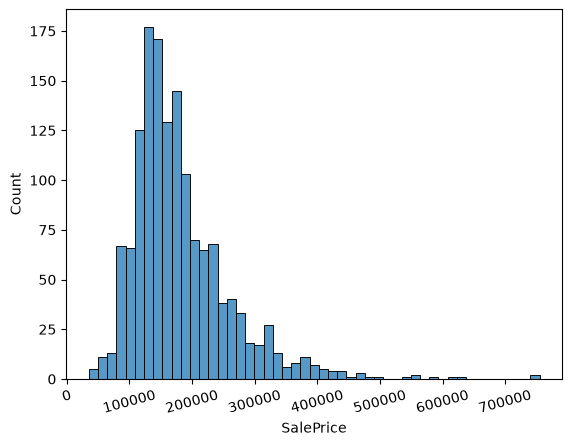

In [145]:
plt.xticks(rotation = 15)
sns.histplot(df['SalePrice'])
plt.show()

<Axes: xlabel='SalePrice', ylabel='Count'>

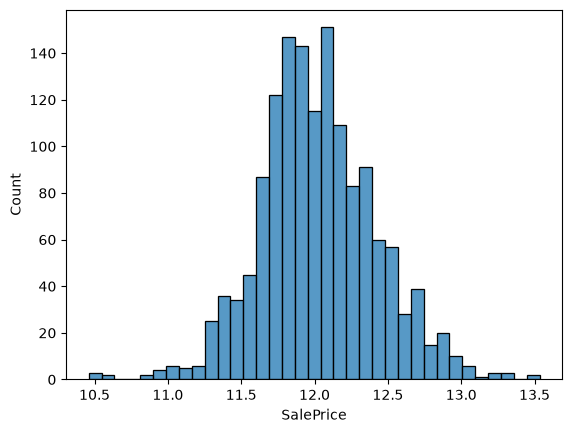

In [146]:
log_SalePrice = np.log1p(df['SalePrice'])
sns.histplot(log_SalePrice)

In [147]:
df['Id'].value_counts() # 여기서 값이 전부 1로 떨어지면 drop 시키면 됨. 다른컬럼도 해보기

Id
1       1
2       1
3       1
4       1
5       1
       ..
1456    1
1457    1
1458    1
1459    1
1460    1
Name: count, Length: 1460, dtype: int64

In [148]:
drop_cols = ['Id', 'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'MasVnrType']

In [149]:
df.drop(drop_cols, axis = 1, inplace = True)

df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000


In [150]:
## 숫자칼럼의 경우 결측치를 평균으로 대체
num_cols = df.dtypes[df.dtypes != 'str'].index

## 데이터타입 : str의 경우 여전히 결측치 남아있음
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000


In [151]:
print(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))

GarageQual      81
GarageCond      81
GarageFinish    81
GarageType      81
BsmtFinType2    38
BsmtExposure    38
BsmtCond        37
BsmtQual        37
BsmtFinType1    37
Electrical       1
dtype: int64


In [152]:
from sklearn.model_selection import train_test_split

X_dum = pd.get_dummies(X)

X_train, X_val, y_train, y_val = train_test_split(X_dum, y, test_size = 0.3, random_state = 42)

print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)

(1022, 266) (438, 266) (1022,) (438,)


In [153]:
test_df = pd.read_csv('./data/house_test.csv')

test_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [154]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   str    
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   str    
 6   Alley          107 non-null    str    
 7   LotShape       1459 non-null   str    
 8   LandContour    1459 non-null   str    
 9   Utilities      1457 non-null   str    
 10  LotConfig      1459 non-null   str    
 11  LandSlope      1459 non-null   str    
 12  Neighborhood   1459 non-null   str    
 13  Condition1     1459 non-null   str    
 14  Condition2     1459 non-null   str    
 15  BldgType       1459 non-null   str    
 16  HouseStyle     1459 non-null   str    
 17  OverallQual    1459 non-null   int64  
 18  OverallCond    1459

In [155]:
test_drop_cols = ['Id', 'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'MasVnrType']

In [156]:
test_df.drop(test_drop_cols, axis = 1, inplace = True)

test_df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,120,0,0,6,2010,WD,Normal
1,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,36,0,0,0,0,12500,6,2010,WD,Normal
2,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,34,0,0,0,0,0,3,2010,WD,Normal
3,60,RL,78.0,9978,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,36,0,0,0,0,0,6,2010,WD,Normal
4,120,RL,43.0,5005,Pave,IR1,HLS,AllPub,Inside,Gtl,...,82,0,0,144,0,0,1,2010,WD,Normal


In [157]:
## 숫자칼럼의 경우 결측치를 평균으로 대체
test_num_cols = test_df.dtypes[test_df.dtypes != 'str'].index

## 데이터타입 : str의 경우 여전히 결측치 남아있음
test_df[test_num_cols] = test_df[test_num_cols].fillna(df[test_num_cols].mean())

test_df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,120,0,0,6,2010,WD,Normal
1,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,36,0,0,0,0,12500,6,2010,WD,Normal
2,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,34,0,0,0,0,0,3,2010,WD,Normal
3,60,RL,78.0,9978,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,36,0,0,0,0,0,6,2010,WD,Normal
4,120,RL,43.0,5005,Pave,IR1,HLS,AllPub,Inside,Gtl,...,82,0,0,144,0,0,1,2010,WD,Normal


In [158]:
print(test_df.isnull().sum()[test_df.isnull().sum() > 0].sort_values(ascending=False))

GarageCond      78
GarageFinish    78
GarageQual      78
GarageType      76
BsmtCond        45
BsmtQual        44
BsmtExposure    44
BsmtFinType1    42
BsmtFinType2    42
MSZoning         4
Utilities        2
Functional       2
Exterior1st      1
Exterior2nd      1
KitchenQual      1
SaleType         1
dtype: int64


In [159]:
test_X_dum = pd.get_dummies(test_df) 


test_X_dum.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,20,80.0,11622,5,6,1961,1961,0.0,468.0,144.0,...,False,False,False,True,False,False,False,False,True,False
1,20,81.0,14267,6,6,1958,1958,108.0,923.0,0.0,...,False,False,False,True,False,False,False,False,True,False
2,60,74.0,13830,5,5,1997,1998,0.0,791.0,0.0,...,False,False,False,True,False,False,False,False,True,False
3,60,78.0,9978,6,6,1998,1998,20.0,602.0,0.0,...,False,False,False,True,False,False,False,False,True,False
4,120,43.0,5005,8,5,1992,1992,0.0,263.0,0.0,...,False,False,False,True,False,False,False,False,True,False


In [160]:
print(X_dum.shape)
print(test_X_dum.shape)

(1460, 266)
(1459, 250)


In [161]:
test_X_dum = test_X_dum.reindex(columns=X_train.columns,
                                fill_value=0)
print(test_X_dum)
print(test_X_dum.shape)

      MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  \
0             20         80.0    11622            5            6       1961   
1             20         81.0    14267            6            6       1958   
2             60         74.0    13830            5            5       1997   
3             60         78.0     9978            6            6       1998   
4            120         43.0     5005            8            5       1992   
...          ...          ...      ...          ...          ...        ...   
1454         160         21.0     1936            4            7       1970   
1455         160         21.0     1894            4            5       1970   
1456          20        160.0    20000            5            7       1960   
1457          85         62.0    10441            5            5       1992   
1458          60         74.0     9627            7            5       1993   

      YearRemodAdd  MasVnrArea  BsmtFinSF1  BsmtFin

In [168]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error

xgb_reg = XGBRegressor(n_estimators = 1000)

lgbm_reg = LGBMRegressor(n_estimators = 1000)
                         

xgb_reg.fit(X_train, y_train)

xgb_pred = xgb_reg.predict(X_val)

xgb_mse = mean_squared_error(y_val, xgb_pred)

xgb_rmse = np.sqrt(xgb_mse)

print(xgb_pred)
print(xgb_mse)
print(xgb_rmse)

[148065.77  369482.97  118560.24  169903.78  314765.78   76072.6
 223757.53  147893.67   78870.016 136872.5   162318.17  113690.66
 113719.414 205140.14  171269.42  130018.805 196466.7   135106.
 132071.34  205944.2   150376.61  229847.14  172238.12  130202.
 196656.5   165575.22  194253.36  104491.25  170033.84  210982.64
 125800.11  272743.56  164365.72  113914.72  243870.4   147656.8
 128087.13  197148.47  285328.9   129237.19  134823.2   239023.92
 124079.53  338788.22  122652.83  135933.2   119968.055 123568.66
 282895.25  141074.73  118938.25  201705.     95577.87  350267.47
 143551.1   230855.72  177529.98  148587.78  149753.19  102617.87
  59905.74  155321.42  305233.72  283822.34  249986.16  244702.84
 109132.26  319284.88  103855.16  171814.05  125958.14  128019.914
 112687.47   78684.21  441245.8   171224.6   331638.22  313547.88
 145695.73  129961.82  104106.055  88548.71  113719.125  97617.19
 161084.17  140659.05  267132.16  192358.36  141325.    162811.72
 135415.81  145

In [170]:
# LightGBM

lgbm_reg.fit(X_train, y_train)

lgbm_pred = lgbm_reg.predict(X_val)

lgbm_mse = mean_squared_error(y_val, lgbm_pred)

lgbm_rmse = np.sqrt(lgbm_mse)


print(lgbm_pred)
print(lgbm_mse)
print(lgbm_rmse)

[139443.24669624 281353.6442301  111723.02029251 164350.23698366
 331276.86616442  77987.54889165 220339.41972305 150824.77130252
  79509.5149511  126183.43454135 153087.80874507 118020.01172162
 118566.68935378 197534.47320171 167121.25414371 125325.25548151
 192492.51927986 127295.84645665 121792.00326046 212663.19933104
 152335.97733486 238291.55861164 171659.81315675 130440.08171665
 201908.41721223 164096.38187906 202230.14712682  98920.58853589
 174675.9660733  219240.67434355 118495.4878322  255226.94628062
 158265.4825538  112815.1868211  248015.07980583 147782.76816064
 124824.07098616 205465.93306618 330382.22080845 116224.86755896
 129993.44900381 229621.61756965 116863.21085297 385284.84602401
 135423.77437144 122673.92300935 121435.6322498  121553.97030769
 449370.11057109 133031.31865621 117546.5796788  201849.63119443
 103724.16550189 399571.23357984 139678.81558913 243359.32953886
 189372.14915251 148443.78043956 134567.359746   110823.48675291
  72920.14050662 155286.6

In [172]:
y_pred_xgb = xgb_reg.predict(test_X_dum)
y_pred_lgbm = lgbm_reg.predict(test_X_dum)

print(y_pred_lgbm.shape, y_pred_xgb.shape)
print(type(y_pred_lgbm), type(y_pred_xgb))

house_pred = pd.DataFrame({"Id": id, "XGB Predict": y_pred_xgb, "LGBM Predict": y_pred_lgbm})

(1459,) (1459,)
<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [173]:
house_pred.to_csv("./data/house_pred.csv", index = False)